# Computing transition matrix with LP

In [11]:
from scipy.spatial.distance import pdist, squareform
import numpy as np
import pandas as pd

In [17]:
# For n vectors of d dimensions
vectors = np.random.rand(10, 100).T  # 1000 vectors, 100 dimensions


In [18]:
vectors.shape

(100, 10)

In [19]:
# Compute condensed distance matrix (upper triangle only)
distances_condensed = pdist(vectors, metric='euclidean')

# Convert to full square matrix if needed
distances_full = squareform(distances_condensed)

In [20]:
distances_full.shape
pd.DataFrame(distances_full)

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.000000,0.940983,1.401640,1.171349,1.104543,1.157673,1.276397,1.040433,1.148214,1.256749,...,1.325200,1.103912,1.431360,1.065406,1.512166,1.090327,1.194567,0.994736,1.191458,1.285450
1,0.940983,0.000000,1.152020,1.020339,1.153070,1.255510,0.767439,1.430137,0.947817,1.292079,...,0.928836,1.022959,1.341531,1.182620,1.282795,0.959947,1.229144,0.911552,0.957698,1.123832
2,1.401640,1.152020,0.000000,1.176258,0.935442,1.014763,1.257066,1.679822,1.349553,1.290374,...,1.079233,1.004550,1.067628,1.096974,1.274374,1.368456,1.129243,1.176277,1.218578,0.827445
3,1.171349,1.020339,1.176258,0.000000,1.033492,1.494657,1.163443,1.150532,0.949872,1.293082,...,0.901655,1.213845,1.294979,1.089422,1.243430,1.114297,1.431107,1.096996,1.347347,1.363593
4,1.104543,1.153070,0.935442,1.033492,0.000000,1.243968,1.160609,1.368860,1.085870,1.316889,...,1.128781,1.188471,0.906272,0.913933,1.073329,1.105442,1.186891,0.881715,1.194610,1.306161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1.090327,0.959947,1.368456,1.114297,1.105442,1.429477,1.421326,1.210860,1.006202,1.194982,...,1.082796,1.309917,1.294615,1.097571,1.049431,0.000000,0.841357,1.214200,1.103808,1.560347
96,1.194567,1.229144,1.129243,1.431107,1.186891,0.970061,1.569760,1.529786,1.351042,1.190913,...,1.198761,1.002347,1.286454,1.189063,1.445580,0.841357,0.000000,1.272389,1.109039,1.180447
97,0.994736,0.911552,1.176277,1.096996,0.881715,0.931914,0.795416,1.262492,1.180712,1.349472,...,0.827927,0.826444,1.497111,1.081936,1.181197,1.214200,1.272389,0.000000,1.143032,1.182385
98,1.191458,0.957698,1.218578,1.347347,1.194610,1.224365,1.446741,1.820585,1.052779,1.242290,...,1.337019,1.152099,1.652029,1.072075,1.428615,1.103808,1.109039,1.143032,0.000000,1.140116


In [13]:
# For Euclidean distance
diff = vectors[:, np.newaxis, :] - vectors[np.newaxis, :, :]  # (n, n, d)
distances = np.linalg.norm(diff, axis=2)

In [14]:
pd.DataFrame(distances)

,0,1,2,3,4,5,6,7,8,9
0,0.000000,4.117890,4.169742,4.308235,3.896386,4.250891,3.979452,3.681038,3.758757,4.283592
1,4.117890,0.000000,3.874329,4.165895,4.359749,4.137787,4.165651,3.772423,4.077648,4.027494
2,4.169742,3.874329,0.000000,4.137201,4.375399,4.369327,4.117058,4.203397,3.782944,3.878438
3,4.308235,4.165895,4.137201,0.000000,4.320965,4.350862,4.022301,3.990987,4.163339,4.458176
4,3.896386,4.359749,4.375399,4.320965,0.000000,3.907819,4.137642,3.911882,4.408194,4.018381
5,4.250891,4.137787,4.369327,4.350862,3.907819,0.000000,3.867572,3.980768,4.639495,4.043480
6,3.979452,4.165651,4.117058,4.022301,4.137642,3.867572,0.000000,3.737323,4.291860,4.081890
7,3.681038,3.772423,4.203397,3.990987,3.911882,3.980768,3.737323,0.000000,3.992588,3.865126
8,3.758757,4.077648,3.782944,4.163339,4.408194,4.639495,4.291860,3.992588,0.000000,4.102452
9,4.283592,4.027494,3.878438,4.458176,4.018381,4.043480,4.081890,3.865126,4.102452,0.000000


In [16]:
from sklearn.metrics.pairwise import pairwise_distances

distances = pairwise_distances(vectors, metric='euclidean')

ModuleNotFoundError: No module named 'sklearn'

In [98]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

def solve_transition_lp(
    D,
    P_prev,
    lam=1.0,
    solver="HIGHs",
    warm_start=True,
    verbose=False
):
    """
    Solve:
        max <D, P> - lam * ||P - P_prev||_1
    subject to:
        P >= 0
        row sums = 1
        col sums = 1
        diag(P) = 0
    """

    d = D.shape[0]

    # Decision variables
    P = cp.Variable((d, d))
    Z = cp.Variable((d, d))

    constraints = []

    # Non-negativity
    constraints += [P >= 0]

    # Row and column stochasticity
    constraints += [cp.sum(P, axis=1) == 1]
    constraints += [cp.sum(P, axis=0) == 1]

    # Zero diagonal
    constraints += [cp.diag(P) == 0]

    # L1 regularization constraints
    constraints += [Z >= P - P_prev]
    constraints += [Z >= -(P - P_prev)]

    # Objective
    objective = cp.Maximize(cp.sum(cp.multiply(D, P)) - lam * cp.sum(Z))

    problem = cp.Problem(objective, constraints)

    problem.solve(
        solver=cp.HIGHS,
        warm_start=warm_start,
        verbose=verbose,
    )

    if problem.status not in ["optimal", "optimal_inaccurate"]:
        raise RuntimeError(f"LP did not solve: {problem.status}")

    return P.value



In [ ]:
d = 1000

# Distance matrix (example: Euclidean on a line)
x = np.linspace(0, 1, d)
D = np.abs(x[:, None] - x[None, :])

# Create a distance matrix based on angular measured between d angles from 0 to 2pi
np.random.seed(0)
angles = np.sort(np.random.uniform(0, 2 * np.pi, d))
print(angles)
abs_angular_dist = np.abs(angles[:, None] - angles[None, :])
D = np.minimum(abs_angular_dist, 2 * np.pi - abs_angular_dist)

# Initial doubly stochastic matrix (uniform, zero diagonal)
P0 = np.ones((d, d)) / (d - 1)
np.fill_diagonal(P0, 0)

# Solve
P1 = solve_transition_lp(D, P0, lam=2, verbose=False)
P1

[3.43039862e-03 8.69184439e-03 1.69847938e-02 2.42553039e-02
 2.95025470e-02 3.23770294e-02 4.95372833e-02 7.18008401e-02
 7.36017616e-02 7.56258189e-02 7.64736345e-02 8.31696302e-02
 9.80557948e-02 1.02595008e-01 1.03230407e-01 1.06007850e-01
 1.16375867e-01 1.18059798e-01 1.20152708e-01 1.20594422e-01
 1.26339439e-01 1.27035938e-01 1.29754056e-01 1.52764339e-01
 1.55061024e-01 1.61243613e-01 1.81914231e-01 1.83407655e-01
 1.88183441e-01 1.89973729e-01 2.00049894e-01 2.07813787e-01
 2.09259140e-01 2.22188737e-01 2.26407152e-01 2.42262322e-01
 2.46224161e-01 2.48911669e-01 2.51282185e-01 2.69700644e-01
 2.80307356e-01 2.89072460e-01 2.94093000e-01 3.05930152e-01
 3.10068577e-01 3.35692884e-01 3.41415650e-01 3.47927116e-01
 3.57186999e-01 3.57370359e-01 3.64607968e-01 3.66663817e-01
 3.67785763e-01 3.73115574e-01 3.76641134e-01 3.78407798e-01
 3.83767767e-01 3.93553614e-01 3.94037099e-01 3.97145179e-01
 3.99320144e-01 4.01842788e-01 4.03050607e-01 4.10318435e-01
 4.12207538e-01 4.156293

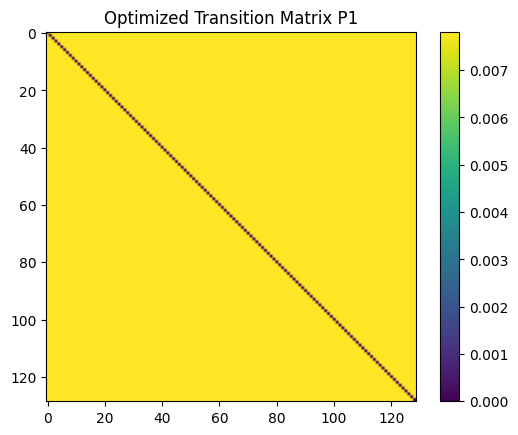

In [107]:
plt.imshow(P1, cmap='viridis')
plt.colorbar()
plt.title('Optimized Transition Matrix P1')
plt.show()

In [108]:
P_matrices = [None] * 7
lambdas = [0.01, 0.05, 0.1, 1, 2, 5, 10]
for j in range(len(lambdas)):
    P_matrices[j] = solve_transition_lp(D, P0, lam=lambdas[j], verbose=False)


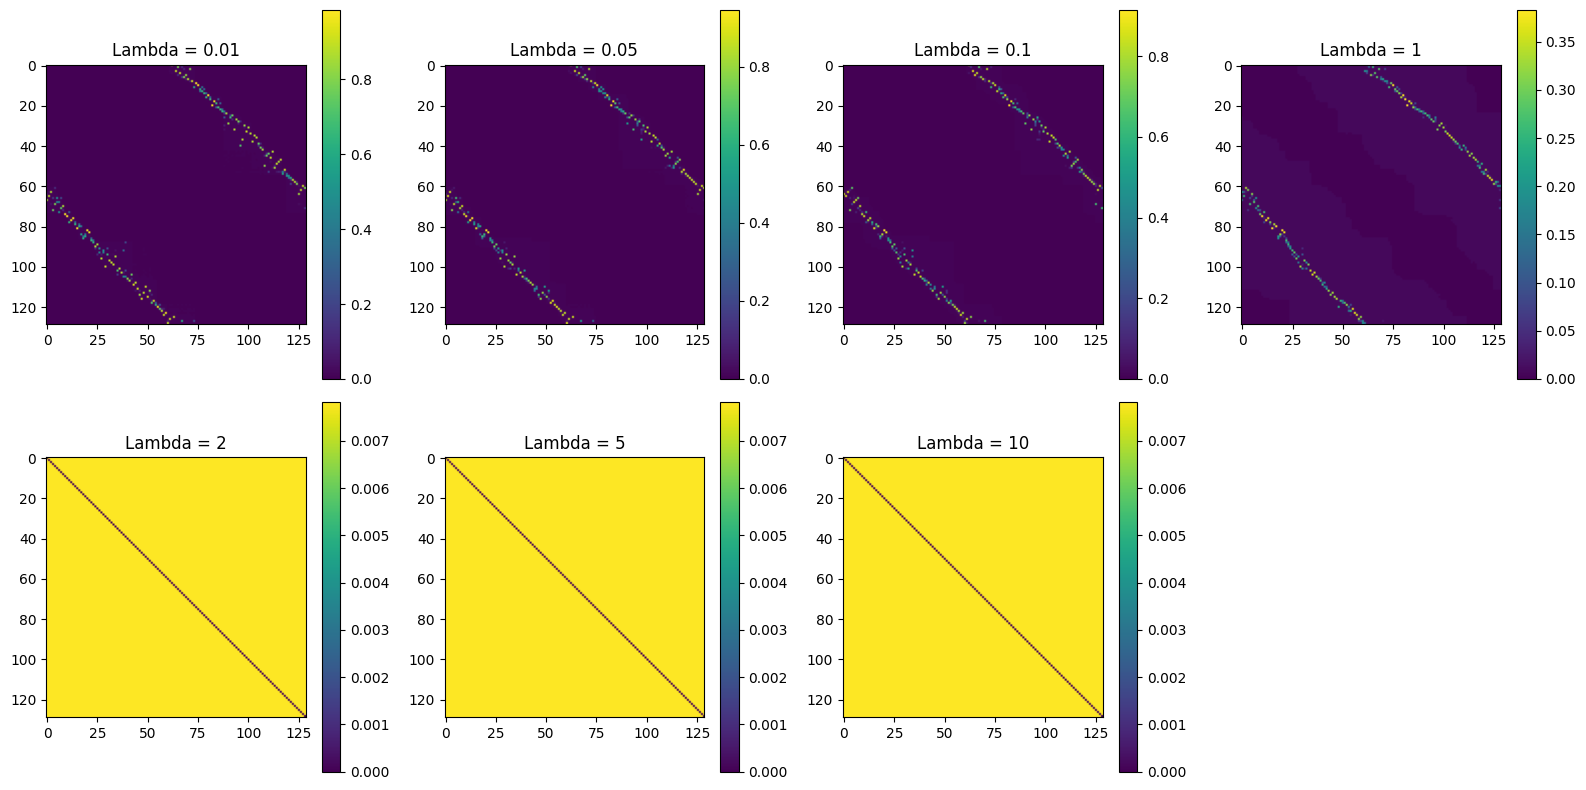

In [109]:
# Plot the transition matrices for different lambda values in a grid
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    if i < len(lambdas):
        im = ax.imshow(P_matrices[i], cmap='viridis')
        ax.set_title(f'Lambda = {lambdas[i]}')
        fig.colorbar(im, ax=ax)
    else:
        ax.axis('off')
plt.tight_layout()
plt.show()